# Codigo intercambiado - Convección natural

## Funciones

In [ ]:
import math

def Q_dot(flujo_masico_coil, Cp_coil, T_coil_in, T_coil_out):
    return flujo_masico_coil * Cp_coil * (T_coil_out - T_coil_in)

def delta_tm(t_coil_in, t_coil_out, t_agua):
    delta_t1 = t_coil_in - t_agua
    delta_t2 = t_coil_out - t_agua
    return (delta_t1 - delta_t2) / math.log(delta_t1 / delta_t2)

'''
Resistencia termica se obtiene con Q = delta_T / R, entonces R = delta_T / Q,
De esta resistencia se obtiene el h_o, es decir convección externa
'''

def calcular_hi(Rth, di, do, k, L, ho):
    """
    Calcula el coeficiente de convección interno h_i
    a partir de la resistencia térmica total de un cilindro.

    Parámetros:
    Rth : resistencia térmica total [K/W]
    di  : diámetro interno coil[m]
    do  : diámetro externo coil[m]
    k   : conductividad térmica del material coil [W/(m·K)]
    L   : longitud del coil [m]
    ho  : coeficiente de convección externo [W/(m²·K)]
    Ao  : área externa coil [m²]

    Retorna:
    h_i : coeficiente de convección interno [W/(m²·K)]
    """

    Ai = math.pi * di * L  # área interna cilíndrica
    Ao = math.pi * do * L  # área externa cilíndrica
    term_conduccion = math.log(do/di) / (2 * math.pi * k * L)
    term_conveccion_ext = 1 / (ho * Ao)

    hi = 1 / (Ai * (Rth - term_conduccion - term_conveccion_ext))
    return hi

def nusselt_turbulento(Re_di, Pr, di, D):
    """
    Calcula el número de Nusselt para flujo turbulento interno en un tubo.

    Parámetros:
    Re_di : número de Reynolds basado en diámetro interno
    Pr    : número de Prandtl del fluido
    di    : diámetro interno del tubo [m]
    D     : diámetro de la bobina

    Retorna:
    Nu_di : número de Nusselt adimensional
    """
    Nu_di = 0.023 * (Re_di**0.85) * (Pr**0.4) * ((di/D)**0.1)
    return Nu_di

def hi_from_nusselt(Nu, k, di):
    """
    Calcula el coeficiente de convección interno h_i
    a partir del número de Nusselt.

    Parámetros:
    Nu : número de Nusselt adimensional
    k  : conductividad térmica del fluido [W/(m·K)]
    di : diámetro interno del tubo [m]

    Retorna:
    h_i : coeficiente de convección interno [W/(m²·K)]
    """
    return (Nu * k) / di

def reynolds(rho, v, di, mu):
    """
    Calcula el número de Reynolds.
    rho : densidad del fluido [kg/m³]
    v   : velocidad promedio [m/s]
    di  : diámetro interno [m]
    mu  : viscosidad dinámica [Pa·s]
    """
    return (rho * v * di) / mu

def prandtl(cp, mu, k):
    """
    Calcula el número de Prandtl.
    cp : calor específico [J/(kg·K)]
    mu : viscosidad dinámica [Pa·s]
    k  : conductividad térmica [W/(m·K)]
    """
    return (cp * mu) / k



In [ ]:


vol_agua = 2 / 1000 #m3
rho_agua = 1000 #kg/m3

d_i = 5.15e-3 #m
d_o = 6.35e-3 #m

In [ ]:
from CoolProp.CoolProp import PropsSI

# Definir fracciones molares de la mezcla
# Ejemplo: 70% agua, 30% etanol
fraction_water = 0.7
fraction_ethanol = 0.3

# Crear mezcla HEOS
fluid = f"HEOS::Water[{fraction_water}]&Ethanol[{fraction_ethanol}]"

# Condiciones de estado
T = 2 + 273   # EJEMPLO TEMP, MODIFICAR
P = 101325   # Presión [Pa] (1 atm)

# Propiedades
rho_coil = PropsSI("D", "T", T, "P", P, fluid)   # densidad [kg/m³]
cp_coil  = PropsSI("C", "T", T, "P", P, fluid)   # calor específico [J/(kg·K)]
mu_coil  = PropsSI("V", "T", T, "P", P, fluid)   # viscosidad dinámica [Pa·s]
k_coil   = PropsSI("L", "T", T, "P", P, fluid)   # conductividad térmica [W/(m·K)]

print(f"Densidad = {rho_coil:.2f} kg/m³")
print(f"Calor específico = {cp_coil:.2f} J/(kg·K)")
print(f"Viscosidad = {mu_coil:.6f} Pa·s")
print(f"Conductividad térmica = {k_coil:.4f} W/(m·K)")


Densidad = 876.67 kg/m³
Calor específico = 3671.76 J/(kg·K)
Viscosidad = 0.003091 Pa·s
Conductividad térmica = 0.6775 W/(m·K)


In [15]:
vel_coil = 1.98 /1000 #m3/s

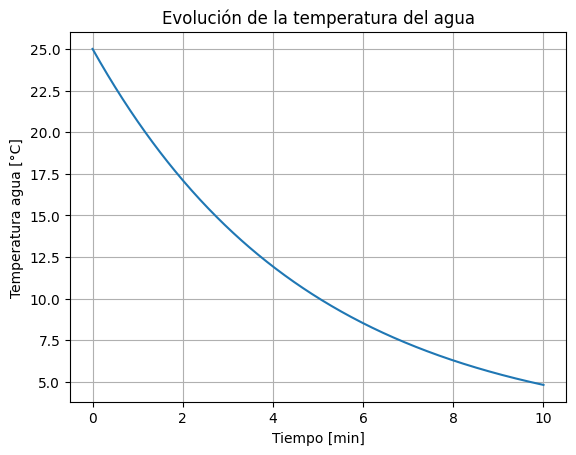

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def enfriamiento_agua(T_inicial, T_coil, hi, Ai, V, rho, cp, tiempo_total, dt=1):
    """
    Simula la evolución de la temperatura del agua en reposo
    dentro de un shell con bobina helicoidal.

    Parámetros:
    T_inicial : temperatura inicial del agua [°C]
    T_coil    : temperatura del refrigerante en la bobina [°C]
    hi        : coeficiente de convección interno [W/(m²·K)]
    Ai        : área interna de intercambio [m²]
    V         : volumen de agua [m³]
    rho       : densidad del agua [kg/m³]
    cp        : calor específico del agua [J/(kg·K)]
    tiempo_total : tiempo de simulación [s]
    dt        : paso de tiempo [s]

    Retorna:
    tiempos, temperaturas
    """
    m = rho * V
    tiempos = np.arange(0, tiempo_total+dt, dt)
    temperaturas = [T_inicial]

    for t in tiempos[1:]:
        T_actual = temperaturas[-1]
        dTdt = (hi * Ai / (m * cp)) * (T_coil - T_actual)
        T_nueva = T_actual + dTdt * dt
        temperaturas.append(T_nueva)

    return tiempos, temperaturas

# Ejemplo de uso
Re_coil = reynolds(rho_coil, vel_coil, d_i, mu_coil)
Pr_coil = prandtl(cp_coil, mu_coil, k_coil)
Nu_coil = nusselt_turbulento(Re_coil, Pr_coil, d_i, d_o) #PUEDE SER QUE d_o TENGA QUE SER D, DIAMETRO DE LA BOBINA REVISAR
hi = hi_from_nusselt(Nu_coil, k_coil, d_i)




T_inicial = 25.0   # °C
T_coil = 2       # °C
Ai = math.pi * d_i * 8  # m² (8 metros de longitud MODIFICAR FUTUO)
V = 0.2/1000   # m³ (10 litros)
rho = 1000.0       # kg/m³
cp = 4180.0        # J/(kg·K)
tiempo_total = 600  # 1 hora

t, T = enfriamiento_agua(T_inicial, T_coil, hi, Ai, V, rho, cp, tiempo_total)

plt.plot(t/60, T)
plt.xlabel("Tiempo [min]")
plt.ylabel("Temperatura agua [°C]")
plt.title("Evolución de la temperatura del agua")
plt.grid(True)
plt.show()
